# Dia 2 · Módulo 4 — Correlação
### Estatística Básica Aplicada · Python

No Dia 1 você aprendeu a descrever **uma** variável: onde ela está, quanto se espalha, que forma
tem. A partir de agora são **duas ao mesmo tempo** — e a pergunta muda:

> ## Quando uma sobe, a outra sobe junto?
> ## E o quanto eu posso confiar num número que resume isso?

A correlação é provavelmente a estatística mais citada e mais mal usada em relatórios e artigos.
Ela cabe em um número entre −1 e +1, é fácil de calcular e **esconde quase tudo** que importa.

**O que a turma vai levar deste módulo:**
1. A correlação nasce da covariância — e existe só para **tirar a unidade** do caminho.
2. **Um único número não descreve uma relação.** Quatro relações opostas dão o mesmo `r`.
3. O `r` é **cego** para curva, para faixa recortada e para um ponto fora do lugar.
4. **Pearson × Spearman** é a mesma escolha robustez × precisão do Módulo 1, agora entre duas variáveis.
5. "Explica 49% da variância" quer dizer muito menos do que parece.

> ⚠️ Você não precisa escrever código do zero: **ler → prever → rodar → interpretar → modificar**.

## Roteiro e tempo

| Seção | Assunto | Ideia central |
|---|---|---|
| ⓪ | Quatro companhias, o mesmo `r` | um número **não** descreve uma relação |
| ① | Da covariância para a correlação | por que foi preciso padronizar |
| ② | O que o `r` não enxerga | curva, faixa recortada, um ponto só |
| ③ | Pearson × Spearman | ordem em vez de valor: robustez de novo |
| ④ | "É forte?" — `r²` e o tamanho da amostra | e o `r` que aparece do nada |
| ⑤ | Decisão: o que reportar ao comando | |

O gancho da seção ⓪ é o **eco direto** do Módulo 3: lá, quatro companhias tinham a mesma média e
o mesmo desvio padrão. Aqui, quatro companhias têm o mesmo `r`.

In [1]:
# --- Preparação do ambiente ---
# numpy: cálculos numéricos | pandas: tabelas | matplotlib: gráficos | scipy: estatística
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)   # 'semente' fixa: todos geram exatamente os mesmos dados aleatórios

# Paleta do curso: cada CONCEITO tem sempre a MESMA cor, em todos os gráficos.
COR = {
    "media":    "#2a78d6",   # azul
    "mediana":  "#eb6834",   # laranja
    "moda":     "#1baf7a",   # verde-água
    "aparada":  "#4a3aa7",   # violeta
    "dados":    "#9ec5f4",   # azul claro (barras, histogramas e nuvens de pontos)
    "pearson":  "#2a78d6",   # azul     — Pearson usa VALOR   (parente da média)
    "spearman": "#eb6834",   # laranja  — Spearman usa ORDEM  (parente da mediana)
    "alerta":   "#e34948",   # vermelho — o ponto ou a região que estraga a conta
}

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": "#52514e", "xtick.color": "#898781", "ytick.color": "#898781",
    "font.size": 10, "lines.linewidth": 2, "figure.dpi": 110,
})

print("Ambiente pronto.")

Ambiente pronto.


---
# ⓪ Quatro companhias, o mesmo `r`

O comando pediu ao S3 um estudo: **horas de treino por semana** têm relação com a **pontuação no
TAF**? O S3 mediu quatro companhias e voltou com a mesma resposta para todas:

> "Correlação de **0,82** nas quatro. Relação forte e positiva. Pode padronizar o treino."

**Antes de rodar:** se as quatro companhias têm o mesmo `r`, o mesmo número de militares, a mesma
média e o mesmo desvio padrão nas duas variáveis — os quatro gráficos precisam ser parecidos,
certo?

In [2]:
# --- As quatro companhias (quarteto de Anscombe, 1973 — números clássicos, rótulo nosso) ---
h_comum = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])   # horas de treino/semana

companhias = {
    "Alfa":    (h_comum, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "Bravo":   (h_comum, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10,  9.13, 7.26, 4.74])),
    "Charlie": (h_comum, np.array([7.46, 6.77,12.74, 7.11, 7.81, 8.84, 6.08, 5.39,  8.15, 6.42, 5.73])),
    "Delta":   (np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]),
                np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}

print(f"{'companhia':>10} | {'média h':>8} | {'média TAF':>10} | {'desvio TAF':>11} | {'r':>6}")
print("-" * 58)
for nome, (h, p) in companhias.items():
    r = stats.pearsonr(h, p).statistic
    print(f"{nome:>10} | {h.mean():>8.2f} | {p.mean():>10.2f} | {p.std(ddof=1):>11.2f} | {r:>6.3f}")

print("\nQuatro companhias. Os MESMOS números resumo. Agora olhe os quatro gráficos.")

 companhia |  média h |  média TAF |  desvio TAF |      r
----------------------------------------------------------
      Alfa |     9.00 |       7.50 |        2.03 |  0.816
     Bravo |     9.00 |       7.50 |        2.03 |  0.816
   Charlie |     9.00 |       7.50 |        2.03 |  0.816
     Delta |     9.00 |       7.50 |        2.03 |  0.817

Quatro companhias. Os MESMOS números resumo. Agora olhe os quatro gráficos.


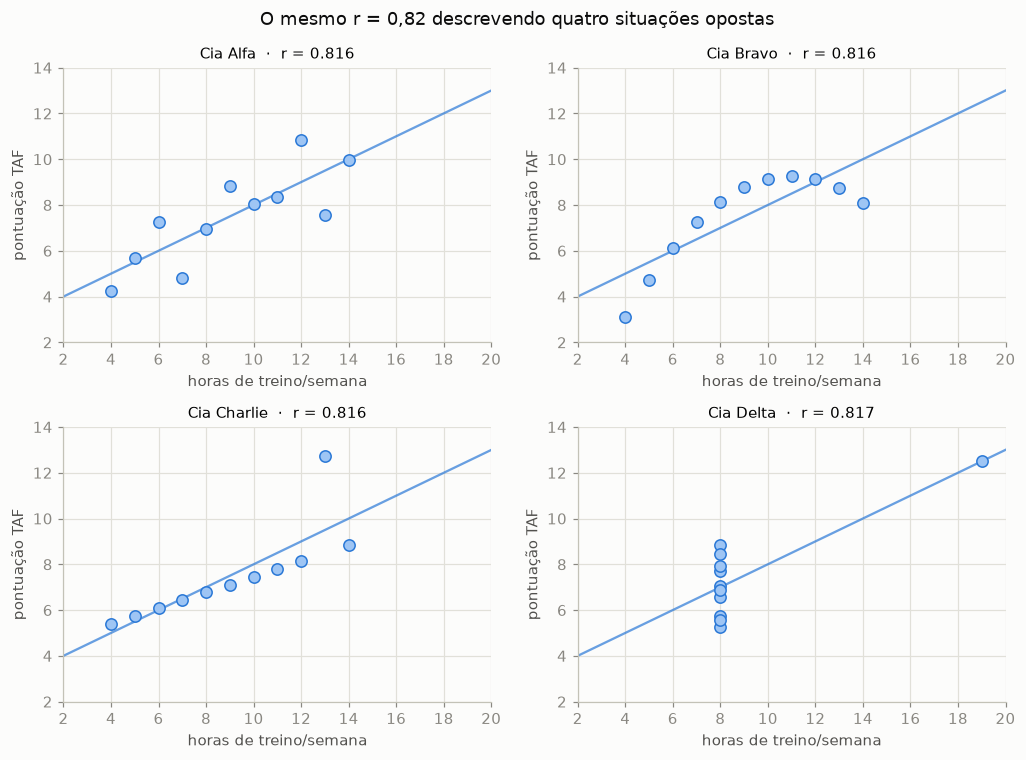

Alfa   : relação linear de verdade. Só nela o r significa o que você achou que significava.
Bravo  : a relação é uma CURVA. A reta e o r são a descrição errada de um fato real.
Charlie: relação quase perfeita + 1 ponto fora. O ponto sozinho derrubou o r.
Delta  : NÃO EXISTE relação. Um único militar (19h) inventou a correlação inteira.


In [3]:
# --- O mesmo r, quatro realidades ---
fig, eixos = plt.subplots(2, 2, figsize=(9.5, 7))
grade_h = np.linspace(2, 20, 50)

for eixo, (nome, (h, p)) in zip(eixos.ravel(), companhias.items()):
    a, b = np.polyfit(h, p, 1)                       # a reta de sempre (Módulo 5)
    eixo.scatter(h, p, color=COR["dados"], edgecolor=COR["pearson"], s=55, zorder=3)
    eixo.plot(grade_h, a * grade_h + b, color=COR["pearson"], linewidth=1.5, alpha=0.7)
    eixo.set_title(f"Cia {nome}  ·  r = {stats.pearsonr(h, p).statistic:.3f}", fontsize=10)
    eixo.set_xlim(2, 20); eixo.set_ylim(2, 14)
    eixo.set_xlabel("horas de treino/semana"); eixo.set_ylabel("pontuação TAF")

fig.suptitle("O mesmo r = 0,82 descrevendo quatro situações opostas", fontsize=12, color="#0b0b0b")
plt.tight_layout()
plt.show()

print("Alfa   : relação linear de verdade. Só nela o r significa o que você achou que significava.")
print("Bravo  : a relação é uma CURVA. A reta e o r são a descrição errada de um fato real.")
print("Charlie: relação quase perfeita + 1 ponto fora. O ponto sozinho derrubou o r.")
print("Delta  : NÃO EXISTE relação. Um único militar (19h) inventou a correlação inteira.")

### O que acabou de acontecer

Este é o quarteto de **Anscombe** (1973), construído justamente para provar o ponto. Nas quatro
companhias, praticamente **tudo** que costuma ir para o relatório é igual: média e desvio padrão
das duas variáveis, o `r`, e até a reta ajustada. E as quatro situações pedem **decisões
opostas** do comando:

| Companhia | O que está acontecendo | O que o comando deveria fazer |
|---|---|---|
| **Alfa** | relação linear real | aumentar as horas de treino |
| **Bravo** | relação em **curva** — o ganho satura e depois cai | achar o ponto ótimo, não empurrar mais treino |
| **Charlie** | relação quase perfeita, **um** militar destoa | investigar aquele militar (lesão? erro de registro?) |
| **Delta** | **não há relação** | não mudar nada — e conferir o dado de 19 h |

> ### 🔑 A ideia central do módulo
> A correlação é um **resumo com perda** — exatamente como a média e o desvio padrão do Dia 1.
> Ela comprime a relação inteira entre duas variáveis em um número, e infinitas relações
> diferentes cabem no mesmo `r`.
>
> **Regra de trabalho: nunca reporte um `r` sem ter olhado o gráfico de dispersão.**
> É a mesma regra do Módulo 3 ("olhe o histograma antes de calcular"), um nível acima.

---
# ① Da covariância para a correlação

Agora que você já desconfia do `r`, vale entender **de onde ele vem** — porque isso explica o que
ele consegue e o que ele não consegue medir.

A ideia bruta é a **covariância**: para cada militar, veja se ele está acima ou abaixo da média
**nas duas** variáveis ao mesmo tempo.

- acima nas duas, ou abaixo nas duas → contribui **positivo**
- acima numa e abaixo na outra → contribui **negativo**

Some tudo e tire a média. Se os "concordantes" ganham, a covariância é positiva.

Repare que isso é **o mesmo desvio em torno da média** do Módulo 2 — só que agora multiplicando
o desvio de duas variáveis em vez de elevar um ao quadrado. (Aliás: a covariância de uma variável
**com ela mesma** é exatamente a variância.)

In [4]:
# --- A companhia que vamos usar no resto do Dia 2 ---
rng = np.random.default_rng(7)
N = 80

idade  = rng.integers(19, 46, N)                                     # anos
horas  = np.clip(rng.normal(6.5, 1.8, N) - 0.04 * (idade - 30), 1.0, None)   # treino/semana
tempo  = 11.2 + 0.055 * (idade - 19) - 0.30 * horas + rng.normal(0, 0.55, N) # corrida 3 km (min)
flex   = 52.0 - 0.45 * (idade - 19) + 1.9 * horas + rng.normal(0, 3.0, N)    # flexões

cia = pd.DataFrame({
    "militar": [f"M{i:02d}" for i in range(1, N + 1)],
    "idade": idade,
    "horas_treino": horas.round(1),
    "tempo_corrida_min": tempo.round(2),
    "flexoes": flex.round(0).astype(int),
})

cia.head(8)

,militar,idade,horas_treino,tempo_corrida_min,flexoes
0,M01,44,5.7,10.96,56
1,M02,35,6.5,10.18,53
2,M03,37,6.3,9.96,59
3,M04,43,3.8,11.32,50
4,M05,34,6.5,8.98,60
5,M06,39,8.6,9.10,65
6,M07,41,3.3,11.63,53
7,M08,25,8.2,7.89,62


In [5]:
# --- Covariância na mão: contando quem "concorda" e quem "discorda" ---
x = cia["horas_treino"].to_numpy()
y = cia["flexoes"].to_numpy()

dx = x - x.mean()          # desvio de cada militar em horas de treino
dy = y - y.mean()          # desvio de cada militar em flexões

concordam = np.sum(dx * dy > 0)    # acima nas duas, ou abaixo nas duas
discordam = np.sum(dx * dy < 0)    # acima numa, abaixo na outra

print(f"militares que CONCORDAM (mesmo lado da média nas duas): {concordam:>3} de {N}")
print(f"militares que DISCORDAM (lados opostos)               : {discordam:>3} de {N}")
print()
cov = np.sum(dx * dy) / (N - 1)
print(f"covariância na mão   = {cov:>8.3f}")
print(f"covariância do numpy = {np.cov(x, y, ddof=1)[0, 1]:>8.3f}")
print()
print("Positiva: quem treina mais tende a fazer mais flexões. Até aqui, tudo bem.")
print(f"O problema é a PERGUNTA SEGUINTE: {cov:.1f} é muito?".replace(".", ","))

militares que CONCORDAM (mesmo lado da média nas duas):  56 de 80
militares que DISCORDAM (lados opostos)               :  24 de 80

covariância na mão   =    5.144
covariância do numpy =    5.144

Positiva: quem treina mais tende a fazer mais flexões. Até aqui, tudo bem.
O problema é a PERGUNTA SEGUINTE: 5,1 é muito?


### O problema da covariância: ela tem unidade

A covariância acima vale **5,1** — mas 5,1 *o quê*? A unidade dela é "hora × flexão", que não
significa nada para ninguém. E, pior: se você mudar a unidade de uma das variáveis, o número muda
**sem que a relação tenha mudado em nada**.

Isso é a mesma armadilha do coeficiente de variação no Módulo 2 (§4.1), pelo avesso: lá o
problema era o **zero** arbitrário, aqui é a **escala** arbitrária.

In [6]:
# --- A mesma relação, três unidades: a covariância muda, a correlação não ---
print(f"{'unidades':<34} | {'covariância':>12} | {'correlação r':>13}")
print("-" * 66)
for rotulo, xx, yy in [
    ("horas/semana  ×  flexões",        x,         y),
    ("MINUTOS/semana  ×  flexões",      x * 60,    y),
    ("horas/semana  ×  DEZENAS de flex", x,        y / 10),
]:
    print(f"{rotulo:<34} | {np.cov(xx, yy, ddof=1)[0, 1]:>12.3f} | "
          f"{stats.pearsonr(xx, yy).statistic:>13.3f}")

print("\nA covariância pulou de 5,1 para 308,6 só porque trocamos hora por minuto.")
print("A correlação NÃO se mexeu: é a covariância dividida pelos dois desvios padrão.")
print("Dividir pelos desvios padrão CANCELA as unidades — sobra um número puro, de -1 a +1.")

unidades                           |  covariância |  correlação r
------------------------------------------------------------------
horas/semana  ×  flexões           |        5.144 |         0.609
MINUTOS/semana  ×  flexões         |      308.611 |         0.609
horas/semana  ×  DEZENAS de flex   |        0.514 |         0.609

A covariância pulou de 5,1 para 308,6 só porque trocamos hora por minuto.
A correlação NÃO se mexeu: é a covariância dividida pelos dois desvios padrão.
Dividir pelos desvios padrão CANCELA as unidades — sobra um número puro, de -1 a +1.


> **A fórmula, agora que ela faz sentido:**
>
> $$r = \frac{\text{covariância}(x,\,y)}{\sigma_x \cdot \sigma_y}$$
>
> A covariância mede a tendência conjunta; a divisão pelos desvios padrão serve **só** para tirar
> as unidades do caminho e prender o resultado entre −1 e +1.
>
> E é justamente essa divisão que faz o `r` ser **cego para a inclinação**: uma relação fraquinha
> e uma relação brutal podem ter o mesmo `r = 0,9`. O `r` diz o quanto os pontos estão **juntos
> da reta**, não o quanto a reta **sobe**. Quem responde "sobe quanto?" é a regressão (Módulo 5).

---
# ② O que o `r` não enxerga

Três cegueiras que aparecem o tempo todo em relatório e em artigo. Todas produzem um `r`
perfeitamente calculável — e perfeitamente enganoso.

## 2.1 · Cegueira nº 1: a relação é uma curva

O caso mais comum na vida real, porque quase nada na natureza é linear para sempre. Treino
demais não é treino bom: existe um ponto em que a carga vira lesão e fadiga.

**Antes de rodar, aposte:** os dados abaixo têm uma relação fortíssima e óbvia entre carga de
treino e desempenho. Quanto vai dar o `r`?

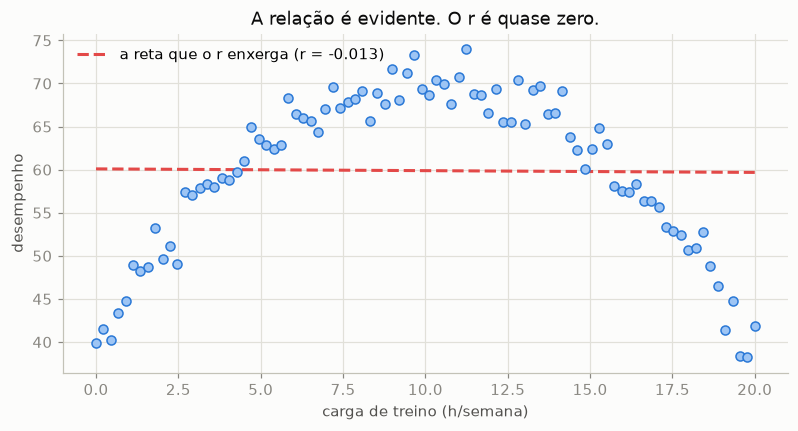

r de Pearson = -0.013  ->  'não há relação linear'
Traduzido errado no relatório: 'treino não tem efeito no desempenho'.
O que os dados dizem: existe um ÓTIMO perto de 10 h/semana, e passar dele PIORA.

O r não mede relação. Mede relação RETA.


In [7]:
# --- Carga de treino × desempenho: a relação existe, mas é um morro ---
carga = np.linspace(0, 20, 90)                                   # horas/semana
desemp = 40 + 6.0 * carga - 0.30 * carga**2 + rng.normal(0, 2.2, 90)   # sobe, satura, desce

r_curva = stats.pearsonr(carga, desemp).statistic

plt.figure(figsize=(8.5, 4))
plt.scatter(carga, desemp, color=COR["dados"], edgecolor=COR["pearson"], s=35, zorder=3)
a, b = np.polyfit(carga, desemp, 1)
plt.plot(carga, a * carga + b, color=COR["alerta"], linestyle="--",
         label=f"a reta que o r enxerga (r = {r_curva:.3f})")
plt.title("A relação é evidente. O r é quase zero.", color="#0b0b0b")
plt.xlabel("carga de treino (h/semana)"); plt.ylabel("desempenho")
plt.legend(frameon=False)
plt.show()

print(f"r de Pearson = {r_curva:.3f}  ->  'não há relação linear'")
print("Traduzido errado no relatório: 'treino não tem efeito no desempenho'.")
print("O que os dados dizem: existe um ÓTIMO perto de 10 h/semana, e passar dele PIORA.")
print("\nO r não mede relação. Mede relação RETA.")

## 2.2 · Cegueira nº 2: a faixa foi recortada

Esta é a mais traiçoeira, porque o recorte quase sempre parece **razoável**.

> O S3 quer saber se as horas de treino explicam o tempo de corrida. Ele analisa apenas os
> militares **aprovados** no TAF — afinal, "os reprovados são casos à parte".

Ao filtrar pelos aprovados, ele jogou fora justamente a faixa onde a relação aparece.

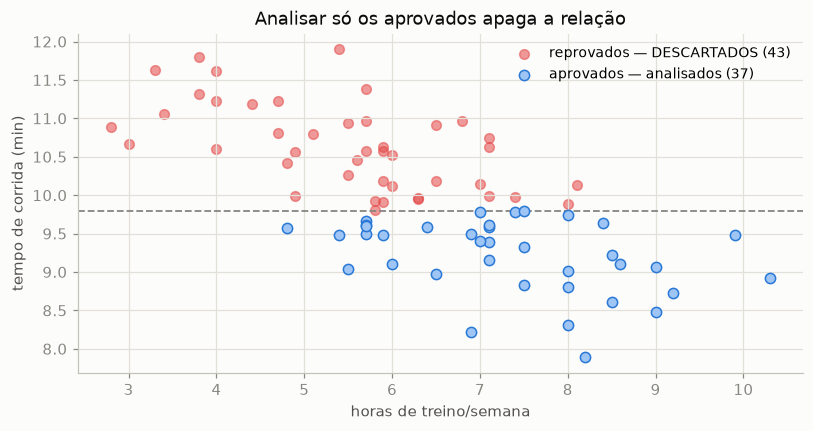

r com a companhia INTEIRA : -0.704   (relação forte)
r só com os APROVADOS     : -0.386   ('relação fraca')

A força da relação caiu quase pela METADE — e nenhum militar mudou de tempo.
Chama-se RESTRIÇÃO DE AMPLITUDE: ao estreitar a faixa do y, você corta a variação
que a correlação precisava para aparecer.

O S3 conclui 'treino explica pouco' — quando na verdade ele mesmo apagou a evidência
ao decidir quem entrava na análise.


In [8]:
# --- O mesmo dado, com e sem recorte pelos aprovados ---
xt = cia["horas_treino"].to_numpy()
yt = cia["tempo_corrida_min"].to_numpy()

LIMITE = 9.8                        # tempo máximo para aprovação no TAF (min)
aprov = yt <= LIMITE

r_todos    = stats.pearsonr(xt, yt).statistic
r_aprovados = stats.pearsonr(xt[aprov], yt[aprov]).statistic

plt.figure(figsize=(8.5, 4))
plt.scatter(xt[~aprov], yt[~aprov], color=COR["alerta"], s=40, alpha=0.55,
            label=f"reprovados — DESCARTADOS ({np.sum(~aprov)})")
plt.scatter(xt[aprov], yt[aprov], color=COR["dados"], edgecolor=COR["pearson"], s=45,
            zorder=3, label=f"aprovados — analisados ({np.sum(aprov)})")
plt.axhline(LIMITE, color="#898781", linestyle="--", linewidth=1.2)
plt.annotate("limite de aprovação", xy=(1.2, LIMITE + 0.08), color="#898781", fontsize=9)
plt.title("Analisar só os aprovados apaga a relação", color="#0b0b0b")
plt.xlabel("horas de treino/semana"); plt.ylabel("tempo de corrida (min)")
plt.legend(frameon=False, fontsize=9)
plt.show()

print(f"r com a companhia INTEIRA : {r_todos:>6.3f}   (relação forte)")
print(f"r só com os APROVADOS     : {r_aprovados:>6.3f}   ('relação fraca')")
print(f"\nA força da relação caiu quase pela METADE — e nenhum militar mudou de tempo.")
print("Chama-se RESTRIÇÃO DE AMPLITUDE: ao estreitar a faixa do y, você corta a variação")
print("que a correlação precisava para aparecer.")
print("\nO S3 conclui 'treino explica pouco' — quando na verdade ele mesmo apagou a evidência")
print("ao decidir quem entrava na análise.")

> **Onde isso te pega na vida real:** sempre que a amostra já passou por um **filtro** ligado às
> variáveis do estudo.
>
> - "correlação entre nota da seleção e desempenho no curso" — medida só em **quem foi aprovado**
>   na seleção;
> - "correlação entre horas de voo e acurácia" — medida só entre **pilotos habilitados**;
> - "relação entre manutenção e disponibilidade" — medida só nas viaturas **que não baixaram**.
>
> Em todos, o `r` sai artificialmente **baixo** e alguém conclui que "o critério de seleção não
> serve para nada". Guarde este caso: ele volta com força no **Módulo 7** (viés de seleção) e é
> primo direto do viés do sobrevivente.

## 2.3 · Cegueira nº 3: um ponto só

O Módulo 2 mostrou que **um** militar destrói uma média e um desvio padrão. Com o `r` é igual —
e o estrago é nos dois sentidos: um ponto pode **criar** uma correlação que não existe (foi a
Cia Delta da seção ⓪) ou **destruir** uma que existe.

**Antes de rodar:** vamos pegar dados sem relação nenhuma e acrescentar **um único** militar com
erro de digitação. Quanto o `r` vai subir?

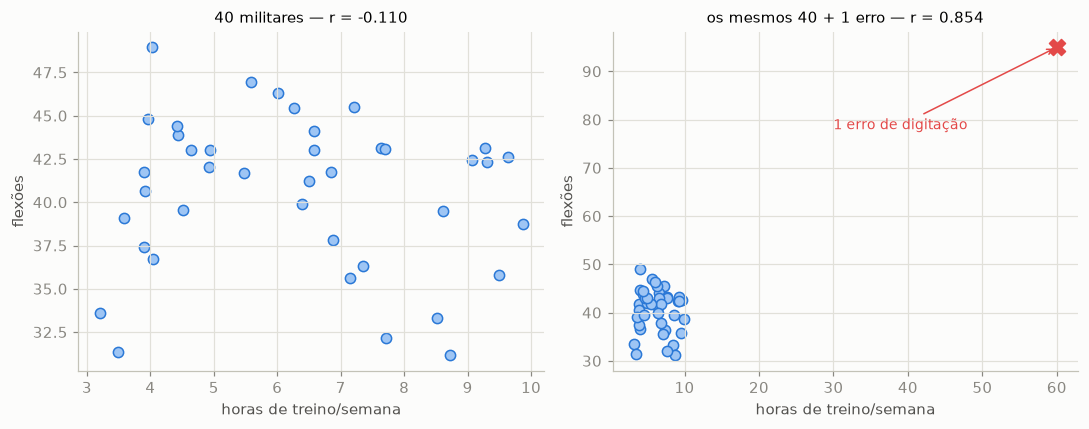

r antes do erro : -0.110   (nenhuma relação)
r depois do erro:  0.854   ('relação forte'!)

1 registro em 41 = 2,4% da base. Foi o suficiente para fabricar a conclusão inteira.


In [9]:
# --- Um erro de digitação inventando uma correlação ---
rng2 = np.random.default_rng(11)
hx = rng2.uniform(3, 10, 40)                 # horas de treino
fy = rng2.normal(40, 5, 40)                  # flexões, SEM relação com horas

# o militar 41: 60 h de treino (digitaram 60 em vez de 6,0) e 95 flexões (95 em vez de 45)
hx_erro = np.append(hx, 60.0)
fy_erro = np.append(fy, 95.0)

fig, (e1, e2) = plt.subplots(1, 2, figsize=(10, 4))
e1.scatter(hx, fy, color=COR["dados"], edgecolor=COR["pearson"], s=45)
e1.set_title(f"40 militares — r = {stats.pearsonr(hx, fy).statistic:.3f}", fontsize=10)
e1.set_xlabel("horas de treino/semana"); e1.set_ylabel("flexões")

e2.scatter(hx_erro[:-1], fy_erro[:-1], color=COR["dados"], edgecolor=COR["pearson"], s=45)
e2.scatter(hx_erro[-1], fy_erro[-1], color=COR["alerta"], s=110, zorder=3, marker="X")
e2.annotate("1 erro de digitação", xy=(60, 95), xytext=(30, 78), color=COR["alerta"], fontsize=9,
            arrowprops=dict(arrowstyle="->", color=COR["alerta"]))
e2.set_title(f"os mesmos 40 + 1 erro — r = {stats.pearsonr(hx_erro, fy_erro).statistic:.3f}",
             fontsize=10)
e2.set_xlabel("horas de treino/semana"); e2.set_ylabel("flexões")

plt.tight_layout()
plt.show()

print(f"r antes do erro : {stats.pearsonr(hx, fy).statistic:>6.3f}   (nenhuma relação)")
print(f"r depois do erro: {stats.pearsonr(hx_erro, fy_erro).statistic:>6.3f}   ('relação forte'!)")
print("\n1 registro em 41 = 2,4% da base. Foi o suficiente para fabricar a conclusão inteira.")

---
# ③ Pearson × Spearman

A cegueira nº 3 tem uma defesa conhecida, e ela é **exatamente a mesma ideia** do Módulo 1: se o
**valor** é frágil, use a **ordem**.

- **Pearson** trabalha com os valores. É parente da **média**: preciso quando os dados são bem
  comportados, destruído por um ponto extremo.
- **Spearman** troca cada valor pela sua **posição na fila** (1º, 2º, 3º…) e calcula Pearson em
  cima disso. É parente da **mediana**: robusto, e enxerga qualquer relação **monótona**, mesmo
  que seja curva.

O militar com 60 h de treino continua sendo o último da fila — mas deixa de ser "dez vezes mais
longe" que os outros. A ordem sobrevive ao erro de digitação; o valor não.

In [10]:
# --- Os dois coeficientes nas três situações do módulo ---
carga_mono = np.linspace(1, 20, 60)
desemp_mono = np.log(carga_mono) * 15 + rng.normal(0, 0.8, 60)   # sobe sempre, mas curvando

# a coluna 'a verdade' NÃO é calculada: nós construímos os dados, então sabemos o que há neles
casos = [
    ("relação reta e limpa",           x,          y,           "existe, e é reta",      "os dois"),
    ("relação em CURVA (morro)",       carga,      desemp,      "existe, sobe e desce",  "NENHUM"),
    ("relação MONÓTONA curva (log)",   carga_mono, desemp_mono, "existe, sempre sobe",   "Spearman"),
    ("sem relação + 1 erro grosseiro", hx_erro,    fy_erro,     "NÃO existe",            "Spearman"),
]

print(f"{'situação':<32} | {'Pearson':>8} | {'Spearman':>9} | {'a verdade':<22} | acertou")
print("-" * 92)
for rotulo, xx, yy, verdade, quem in casos:
    rp = stats.pearsonr(xx, yy).statistic
    rs = stats.spearmanr(xx, yy).statistic
    print(f"{rotulo:<32} | {rp:>8.3f} | {rs:>9.3f} | {verdade:<22} | {quem}")

print("\nLinha 2: a relação EXISTE e os dois dão ~0. Spearman não salva relação em morro,")
print("         porque ela não é monótona — sobe e depois desce.")
print("Linha 3: curva, mas sempre crescente. Spearman dá 0,99 e acerta em cheio;")
print("         Pearson dá 0,94 e subestima, porque a relação não é uma RETA.")
print("Linha 4: NÃO há relação. Pearson comprou o erro de digitação inteiro e cravou 0,85;")
print("         Spearman ficou em ~0,00 e não caiu na armadilha.")
print("\nNenhum coeficiente salva você de não olhar o gráfico.")

situação                         |  Pearson |  Spearman | a verdade              | acertou
--------------------------------------------------------------------------------------------
relação reta e limpa             |    0.609 |     0.593 | existe, e é reta       | os dois
relação em CURVA (morro)         |   -0.013 |    -0.004 | existe, sobe e desce   | NENHUM
relação MONÓTONA curva (log)     |    0.938 |     0.993 | existe, sempre sobe    | Spearman
sem relação + 1 erro grosseiro   |    0.854 |    -0.006 | NÃO existe             | Spearman

Linha 2: a relação EXISTE e os dois dão ~0. Spearman não salva relação em morro,
         porque ela não é monótona — sobe e depois desce.
Linha 3: curva, mas sempre crescente. Spearman dá 0,99 e acerta em cheio;
         Pearson dá 0,94 e subestima, porque a relação não é uma RETA.
Linha 4: NÃO há relação. Pearson comprou o erro de digitação inteiro e cravou 0,85;
         Spearman ficou em ~0,00 e não caiu na armadilha.

Nenhum coeficiente salv

### Qual usar

| Situação | Use | Por quê |
|---|---|---|
| dados bem comportados, relação reta | **Pearson** | mais preciso, e é o que todo mundo reporta |
| suspeita de erro de registro / extremos | **Spearman** | a ordem sobrevive ao valor errado |
| relação curva mas sempre no mesmo sentido | **Spearman** | ele mede **monotonia**, não retidão |
| escala **ordinal** (conceito A/B/C, escala 1-5) | **Spearman** | o valor não tem significado métrico |
| relação em **morro** (sobe e desce) | **nenhum** | os dois dão ~0; descreva por faixas |

> **Regra prática honesta:** calcule os dois. Se derem parecido, reporte Pearson e siga a vida.
> Se derem **muito diferente**, isso não é um detalhe técnico — é um **aviso** de que existe
> algo na forma dos dados (extremo, curva, escala) que você ainda não olhou.

---
# ④ "É forte?" — `r²` e o tamanho da amostra

## 4.1 · O que "explica 49% da variância" quer dizer

Ao elevar o `r` ao quadrado, você obtém a fração da variação de `y` que anda junto com `x`.
`r = 0,7` → `r² = 0,49` → "explica 49% da variância".

Duas advertências, nesta ordem de importância:

1. **"Explica" é vocabulário estatístico, não causal.** Significa "anda junto com", nada mais.
   Isso é o Módulo 6 inteiro.
2. O `r` **exagera a impressão**. Um `r` que parece respeitável costuma sobrar bem pouco depois
   do quadrado — e é o `r²` que corresponde à sua real capacidade de prever.

In [11]:
# --- A tradução honesta do r ---
print(f"{'r':>6} | {'r²':>6} | {'sobra de variação NÃO explicada':>32}")
print("-" * 52)
for r_ in [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]:
    print(f"{r_:>6.2f} | {r_**2:>6.2f} | {1 - r_**2:>31.0%}")

print("\nUm r = 0,5 — que muita gente chama de 'correlação moderada' — deixa 75% da variação")
print("do y sem nenhuma relação com o x. Você acertaria muito pouco prevendo a partir dele.")

     r |     r² |  sobra de variação NÃO explicada
----------------------------------------------------
  0.10 |   0.01 |                             99%
  0.30 |   0.09 |                             91%
  0.50 |   0.25 |                             75%
  0.70 |   0.49 |                             51%
  0.80 |   0.64 |                             36%
  0.90 |   0.81 |                             19%
  0.95 |   0.90 |                             10%

Um r = 0,5 — que muita gente chama de 'correlação moderada' — deixa 75% da variação
do y sem nenhuma relação com o x. Você acertaria muito pouco prevendo a partir dele.


## 4.2 · O `r` que aparece do nada

Com poucos militares, **acaso vira correlação**. Este é o motivo pelo qual um `r` sem o tamanho
da amostra ao lado é um número incompleto.

**Antes de rodar:** vamos sortear duas variáveis **totalmente independentes** (sem nenhuma
relação real), com 8 militares, e repetir isso 5.000 vezes. Em que fração das vezes o `r` vai
passar de 0,6 — "correlação forte", pelos rótulos usuais?

In [12]:
# --- Correlação do nada: duas variáveis independentes, amostras pequenas ---
rng3 = np.random.default_rng(21)
REPETICOES = 5000

print(f"{'militares medidos':>18} | {'|r| médio':>10} | {'|r| > 0,6':>10} | {'|r| > 0,8':>10}")
print("-" * 58)
for n in [5, 8, 15, 30, 80, 300]:
    a = rng3.normal(size=(REPETICOES, n))
    b = rng3.normal(size=(REPETICOES, n))
    az = (a - a.mean(axis=1, keepdims=True)) / a.std(axis=1, keepdims=True)
    bz = (b - b.mean(axis=1, keepdims=True)) / b.std(axis=1, keepdims=True)
    rr = np.abs((az * bz).mean(axis=1))
    print(f"{n:>18} | {rr.mean():>10.3f} | {np.mean(rr > 0.6):>9.1%} | {np.mean(rr > 0.8):>9.1%}")

print("\nNão existe relação nenhuma entre as variáveis — os dados são ruído puro.")
print("Com 5 militares, quase 30% das análises encontram 'correlação forte' (|r| > 0,6).")
print("Com 300, praticamente nunca. É o √n do Módulo 2 trabalhando de novo.")
print("\nMORAL: 'r = 0,72' sem o n ao lado não é informação. É metade de uma informação.")

 militares medidos |  |r| médio |  |r| > 0,6 |  |r| > 0,8
----------------------------------------------------------
                 5 |      0.427 |     28.7% |     10.6%
                 8 |      0.316 |     12.0% |      1.8%
                15 |      0.219 |      1.9% |      0.1%
                30 |      0.150 |      0.1% |      0.0%
                80 |      0.089 |      0.0% |      0.0%


               300 |      0.046 |      0.0% |      0.0%

Não existe relação nenhuma entre as variáveis — os dados são ruído puro.
Com 5 militares, quase 30% das análises encontram 'correlação forte' (|r| > 0,6).
Com 300, praticamente nunca. É o √n do Módulo 2 trabalhando de novo.

MORAL: 'r = 0,72' sem o n ao lado não é informação. É metade de uma informação.


> Repare no que a tabela **não** diz: ela não diz que amostra grande resolve tudo. Ela resolve
> este problema específico (o `r` fabricado pelo acaso). Amostra grande **não** conserta faixa
> recortada, não conserta curva e não conserta erro de digitação sistemático — e não transforma
> correlação em causa.
>
> Quanto de `r` é "demais para ser acaso" é exatamente a pergunta que o **Módulo 8** responde
> com intervalo de confiança e p-valor.

---
# ⑤ Decisão: o que reportar ao comando

| A pergunta real é... | Reporte | Por quê |
|---|---|---|
| as duas variáveis andam juntas? | **`r` + o gráfico de dispersão** | o número sozinho esconde curva e ponto extremo (§⓪) |
| o quanto isso vale para prever | **`r²`**, e em porcentagem | o `r` exagera a impressão (§4.1) |
| dá para confiar neste `r`? | **`r` e o `n` juntos**, sempre | com n pequeno o acaso fabrica `r` (§4.2) |
| há suspeita de erro de registro | **Pearson e Spearman lado a lado** | divergência entre os dois é um alarme (§③) |
| a amostra passou por algum filtro | **diga qual filtro** | faixa recortada derruba o `r` (§2.2) |
| "então A causa B?" | **nada ainda** | isso é o Módulo 6 — e a resposta em geral é não |

### Três frases para levar

1. **Um `r` sem gráfico é um boato.** Quatro relações opostas cabem no mesmo número.
2. **O `r` mede reta, não relação.** Curva, faixa recortada e um ponto fora do lugar são
   invisíveis para ele.
3. **`r` sem `n` é meia informação** — e mesmo `r` alto com `n` grande ainda não é causa.

---
# ⑥ Exercícios

**Exercício 1 — Preveja antes de rodar.**

Volte às quatro companhias da seção ⓪, sem executar nada:

1. Em qual delas **remover um único militar** muda mais o `r`?
2. Em qual delas o **Spearman** vai discordar mais do Pearson?
3. Na Cia Bravo, se o comando aumentar as horas de treino de 8 para 14, o que acontece com a
   pontuação — segundo a reta, e segundo os dados?

**Exercício 2 — Mude um parâmetro.**

Na célula da §2.2, mude o `LIMITE` de aprovação para 11,0 (quase ninguém reprova) e depois para
9,2 (critério duro). Anote o `r` dos aprovados nos dois casos. Pergunta: quanto mais **exigente**
o critério, o `r` sobe ou desce? Por quê? E o que acontece com o `r` quando o limite é tão frouxo
que **ninguém** é reprovado?

**Exercício 3 — Conserte o erro (conceitual, não de sintaxe).**

Um relatório afirma:

> "Encontramos correlação de **0,78** entre horas de manutenção preventiva e disponibilidade da
> viatura (n = 9). Concluímos que a preventiva **explica 78%** da disponibilidade e recomendamos
> dobrar a carga de preventiva em toda a OM."

Há **três** erros conceituais nessa frase. Encontre os três.

**Exercício 4 — Interprete (discussão em grupo).**

O S4 apresenta: *"a correlação entre o consumo de combustível e a quilometragem das viaturas é
r = 0,93 — como esperado. Já entre consumo e idade da viatura é r = 0,11, então a idade não
influencia o consumo."*

1. A primeira correlação é informativa ou é apenas uma **definição disfarçada**?
2. Que gráfico você pede antes de aceitar a segunda conclusão?
3. Se as viaturas mais velhas rodam menos (porque ficam na garagem), o que isso faz com o
   `r = 0,11`? Qual das três cegueiras da §② é essa?

---
## Resumo do módulo

| Ferramenta | Para quê | Cuidado |
|---|---|---|
| **Gráfico de dispersão** | ver a relação — é o primeiro gráfico, sempre | nenhum; é o padrão-ouro |
| **Covariância** | a matéria-prima: variação conjunta | tem unidade — não é comparável |
| **`r` de Pearson** | força da relação **linear**, de −1 a +1 | cego para curva, faixa e extremo |
| **`r` de Spearman** | força da relação **monótona**, via ordem | não salva relação em morro |
| **`r²`** | fração da variação que anda junto | "explica" ≠ causa |
| **`r` + `n`** | dá contexto ao número | `r` sozinho, com n pequeno, é ruído |

- A correlação é um **resumo com perda**: quatro realidades cabem no mesmo `r` (Anscombe).
- **Pearson é parente da média; Spearman é parente da mediana.** A escolha robustez × precisão
  do Módulo 1 reaparece inteira.
- Dividir pelos desvios padrão **tira a unidade** — e é por isso que o `r` não diz "sobe quanto".

➡️ **Próximo módulo:** o `r` diz que duas variáveis andam juntas, mas não diz **quanto** uma
sobe quando a outra sobe — nem permite prever um caso novo. Para isso é preciso traçar a reta, e
a reta vai nascer exatamente da mesma régua do quadrado que definiu a média no Módulo 1.